In [2]:
import numpy as np
import pickle
import lzma
import matplotlib.pyplot as plt
import glob

In [3]:
# record_file = "../record_6.npz"
record_file = "../runs/simpletrack_recorded_1.npz"
print(f"Loading record file: {record_file}")

with lzma.open(record_file, "rb") as file:
    data = pickle.load(file)

print(f"Loaded {len(data)} snapshots")

Loading record file: ../runs/simpletrack_recorded_1.npz
package_folder: /home/teclis/Projects/ML/ML_car/RallyRobotPilot_2025/.venv/lib/python3.13/site-packages/ursina
asset_folder: /home/teclis/Projects/ML/ML_car/RallyRobotPilot_2025/.venv/lib/python3.13/site-packages
Loaded 470 snapshots


### Looking at our data

cleaning up data


In [4]:
def cleanup_recording(data):
    cleaned_data = []

    for snapshot in data:
        # Check if car is moving or any control is pressed
        has_speed = snapshot.car_speed > 0.01  # Small threshold for floating point
        has_control = any(snapshot.current_controls)  # Any control pressed

        # Keep frame if car is moving OR controls are pressed
        if has_speed or has_control:
            cleaned_data.append(snapshot)

    print(f"Original frames: {len(data)}")
    print(f"Cleaned frames: {len(cleaned_data)}")
    print(f"Removed {len(data) - len(cleaned_data)} idle frames")

    return cleaned_data


# Clean the data
data = cleanup_recording(data)

Original frames: 470
Cleaned frames: 463
Removed 7 idle frames


In [5]:
# List all attributes of a snapshot
print("=== Snapshot Attributes ===")
sample_snapshot = data[0]
for attr in dir(sample_snapshot):
    if not attr.startswith('_'):  # Skip private attributes
        value = getattr(sample_snapshot, attr)
        if not callable(value):  # Skip methods
            print(f"{attr}: {type(value).__name__}")

print("\n=== Sample Values from First Snapshot ===")
print(f"current_controls: {sample_snapshot.current_controls}")
print(f"car_position: {sample_snapshot.car_position}")
print(f"car_speed: {sample_snapshot.car_speed}")
print(f"car_angle: {sample_snapshot.car_angle}")
print(f"raycast_distances: {len(sample_snapshot.raycast_distances)} sensors")
print(f"image: {sample_snapshot.image.shape if sample_snapshot.image is not None else 'None'}")

print("\n=== Available Data Columns ===")
print("- current_controls: (forward, backward, left, right) - 4 booleans")
print("- car_position: (x, y, z) - 3 floats")
print("- car_speed: scalar float")
print("- car_angle: rotation_y in degrees")
print("- raycast_distances: list of 15 distance values")
print("- image: RGB image array (H, W, 3) or None")

=== Snapshot Attributes ===
car_angle: float
car_position: tuple
car_speed: float
current_controls: tuple
image: NoneType
raycast_distances: tuple

=== Sample Values from First Snapshot ===
current_controls: (1, 0, 0, 0)
car_position: (-0.25, 1.0, -1.0927847071684482e-08)
car_speed: 2.5
car_angle: -90.0
raycast_distances: 15 sensors
image: None

=== Available Data Columns ===
- current_controls: (forward, backward, left, right) - 4 booleans
- car_position: (x, y, z) - 3 floats
- car_speed: scalar float
- car_angle: rotation_y in degrees
- raycast_distances: list of 15 distance values
- image: RGB image array (H, W, 3) or None


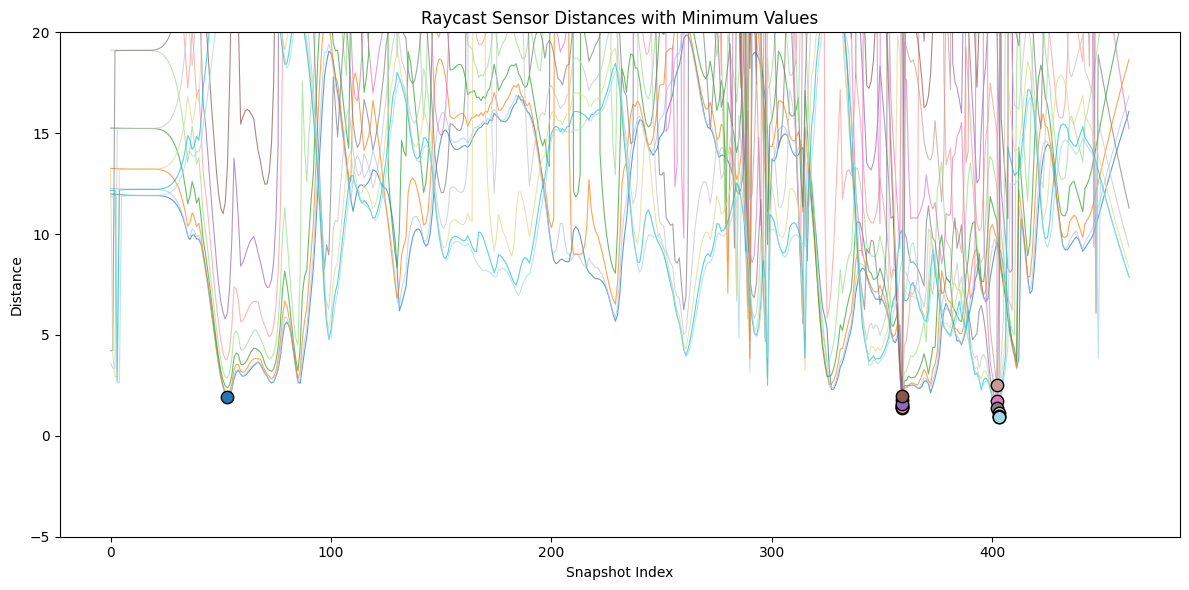

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Collect sensor data
sensor_data = np.array([snapshot.raycast_distances for snapshot in data])  # shape: (num_snapshots, 15)

num_sensors = sensor_data.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, num_sensors))

plt.figure(figsize=(12, 6))

for i in range(num_sensors):
    y = sensor_data[:, i]
    # Plot thin line
    plt.plot(y, color=colors[i], linewidth=0.8, alpha=0.7)

    # Find minimum and its index
    min_idx = np.argmin(y)
    min_val = y[min_idx]

    # Mark minimum
    plt.scatter(min_idx, min_val, color=colors[i], s=80, marker='o', edgecolor='black', zorder=5)

plt.ylim(-5, 20)
plt.xlabel("Snapshot Index")
plt.ylabel("Distance")
plt.title("Raycast Sensor Distances with Minimum Values")
plt.tight_layout()
plt.show()


Sensor 1: min distance between 350-400 = 2.14 at index 372
Sensor 2: min distance between 350-400 = 1.76 at index 359
Sensor 3: min distance between 350-400 = 1.54 at index 359
Sensor 4: min distance between 350-400 = 1.43 at index 359
Sensor 5: min distance between 350-400 = 1.40 at index 359
Sensor 6: min distance between 350-400 = 1.45 at index 359
Sensor 7: min distance between 350-400 = 1.57 at index 359
Sensor 8: min distance between 350-400 = 1.98 at index 359
Sensor 9: min distance between 350-400 = 3.00 at index 359
Sensor 10: min distance between 350-400 = 2.98 at index 400
Sensor 11: min distance between 350-400 = 2.36 at index 400
Sensor 12: min distance between 350-400 = 2.03 at index 400
Sensor 13: min distance between 350-400 = 1.87 at index 400
Sensor 14: min distance between 350-400 = 1.82 at index 400
Sensor 15: min distance between 350-400 = 1.85 at index 400


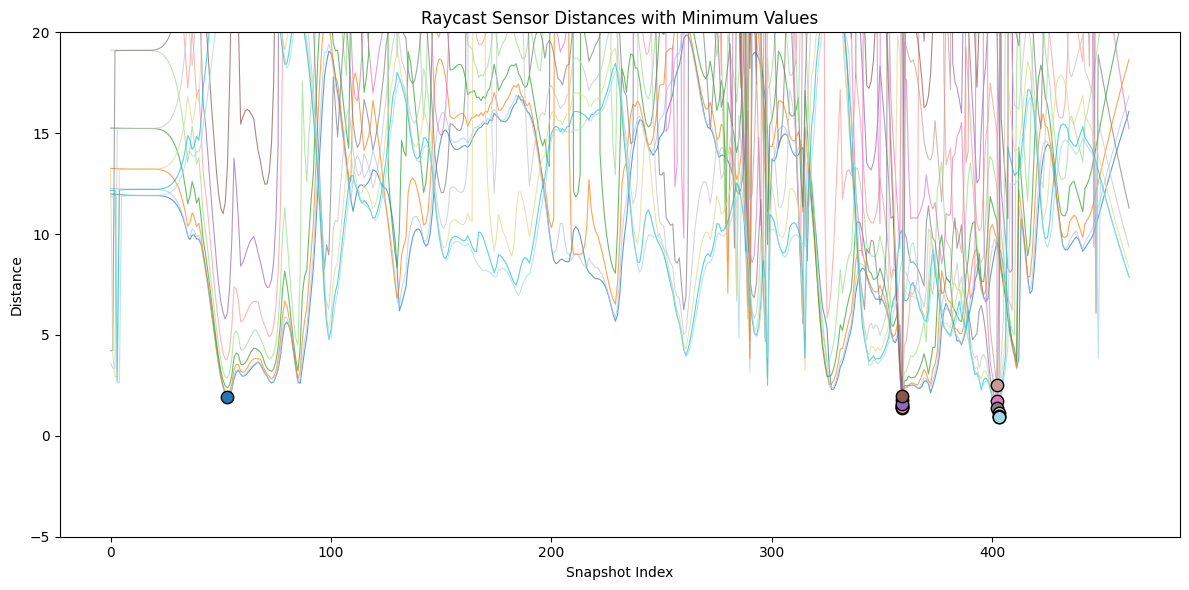

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Collect sensor data
sensor_data = np.array([snapshot.raycast_distances for snapshot in data])  # shape: (num_snapshots, 15)
num_sensors = sensor_data.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, num_sensors))

plt.figure(figsize=(12, 6))

for i in range(num_sensors):
    y = sensor_data[:, i]
    # Plot thin line
    plt.plot(y, color=colors[i], linewidth=0.8, alpha=0.7)

    # Find minimum and its index
    min_idx = np.argmin(y)
    min_val = y[min_idx]

    # Mark minimum
    plt.scatter(min_idx, min_val, color=colors[i], s=80, marker='o', edgecolor='black', zorder=5)

    # Minimum between indices 350 and 400
    subrange = y[350:401]  # include 400
    sub_min = subrange.min()
    sub_min_idx = 350 + np.argmin(subrange)
    print(f"Sensor {i+1}: min distance between 350-400 = {sub_min:.2f} at index {sub_min_idx}")

plt.ylim(-5, 20)
plt.xlabel("Snapshot Index")
plt.ylabel("Distance")
plt.title("Raycast Sensor Distances with Minimum Values")
plt.tight_layout()
plt.show()


### Printing location data

Trying to find out which coordinate from x, y , z is constant.

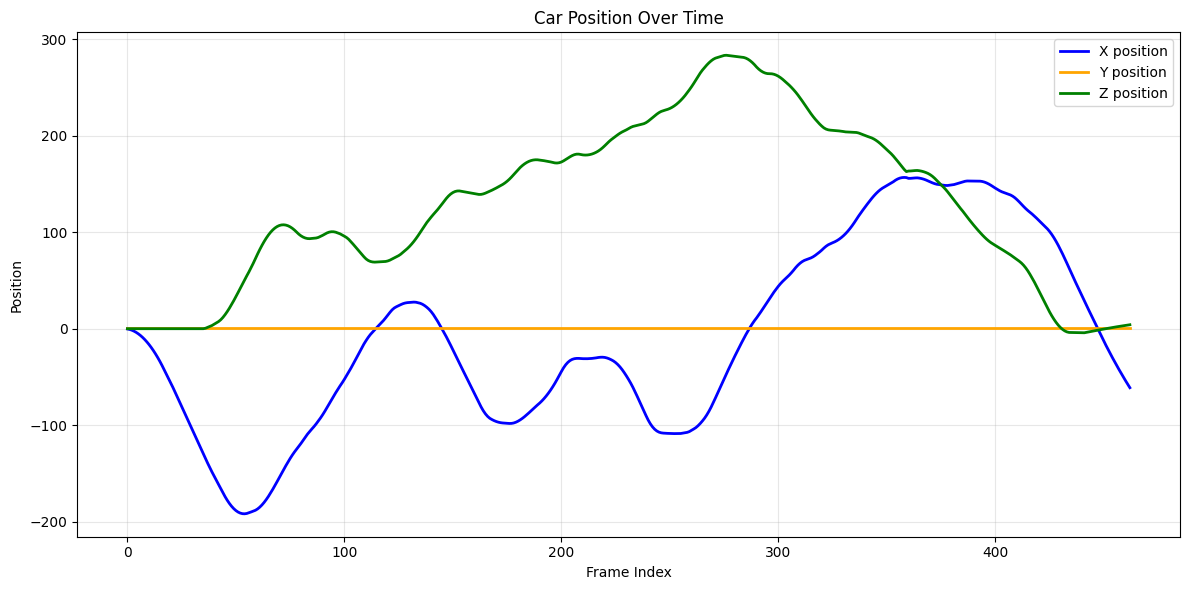

In [8]:
import matplotlib.pyplot as plt

# Extract data
indices = list(range(len(data)))
x_values = [s.car_position[0] for s in data]
y_values = [s.car_position[1] for s in data]
z_values = [s.car_position[2] for s in data]

# Create plot
plt.figure(figsize=(12, 6))
plt.plot(indices, x_values, color='blue', label='X position', linewidth=2)
plt.plot(indices, y_values, color='orange', label='Y position', linewidth=2)
plt.plot(indices, z_values, color='green', label='Z position', linewidth=2)

plt.xlabel('Frame Index')
plt.ylabel('Position')
plt.title('Car Position Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

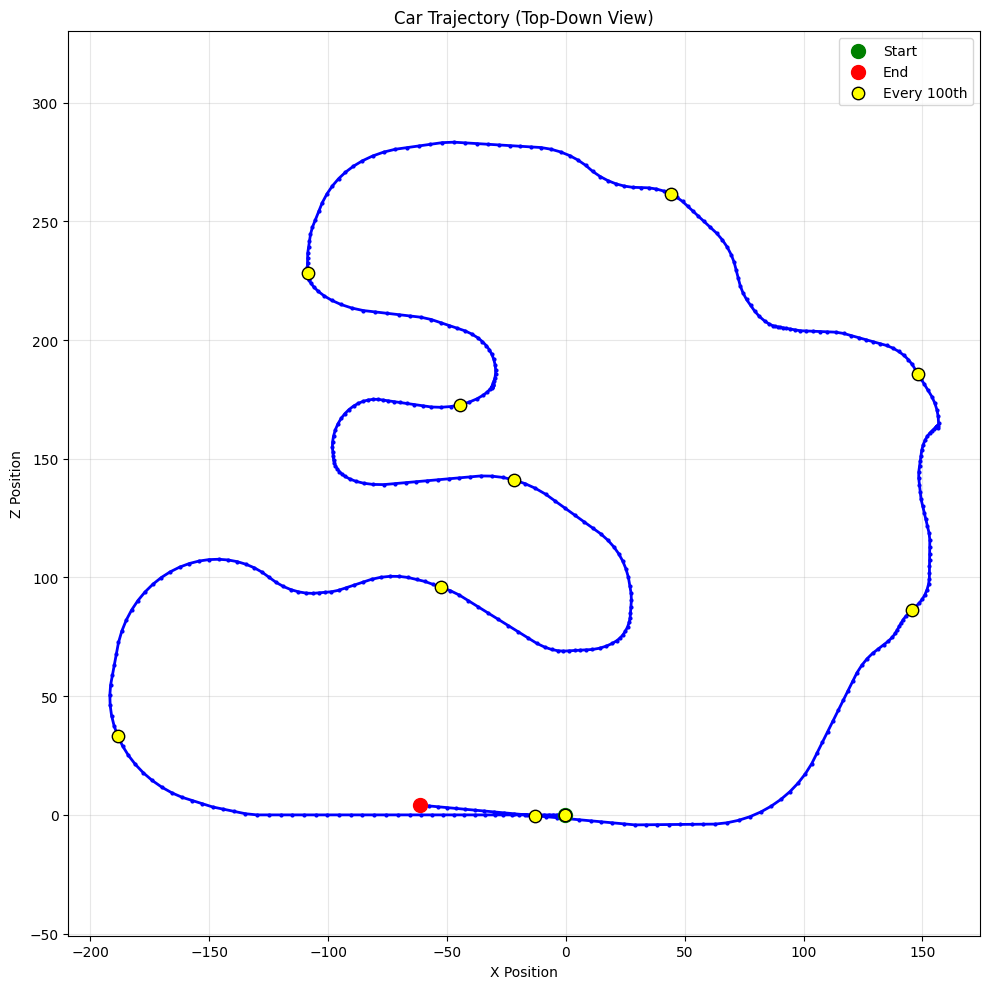

In [9]:
import matplotlib.pyplot as plt

# Extract X and Z positions
x_values = [s.car_position[0] for s in data]
z_values = [s.car_position[2] for s in data]

plt.figure(figsize=(10, 10))
plt.plot(x_values, z_values, color='blue', linewidth=2, marker='o', markersize=2)

# Mark start and end
plt.scatter(x_values[0], z_values[0], color='green', s=100, label='Start', zorder=5)
plt.scatter(x_values[-1], z_values[-1], color='red', s=100, label='End', zorder=5)

# Special markers for multiples of 100
indices_100 = list(range(0, len(x_values), 50))
plt.scatter([x_values[i] for i in indices_100],
            [z_values[i] for i in indices_100],
            color='yellow', s=80, edgecolor='black', label='Every 100th', zorder=6)

plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.title('Car Trajectory (Top-Down View)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [10]:
# Get the very first snapshot (start/finish position)
start_snapshot = data[0]

print("=== Start/Finish Position ===")
print(f"X: {start_snapshot.car_position[0]}")
print(f"Y: {start_snapshot.car_position[1]}")
print(f"Z: {start_snapshot.car_position[2]}")
print(f"Speed: {start_snapshot.car_speed}")
print(f"Orientation (angle): {start_snapshot.car_angle}°")
print(f"Controls (forward, back, left, right): {start_snapshot.current_controls}")

=== Start/Finish Position ===
X: -0.25
Y: 1.0
Z: -1.0927847071684482e-08
Speed: 2.5
Orientation (angle): -90.0°
Controls (forward, back, left, right): (1, 0, 0, 0)


In [11]:
import numpy as np

def calculate_checkpoint_line(snapshot, width=10.0):
    # Extract car position and orientation
    x, y, z = snapshot.car_position
    angle = snapshot.car_angle  # In degrees

    # Calculate perpendicular angle (90 degrees to car's facing direction)
    perpendicular_angle = angle + 90.0

    # Convert to radians for trigonometry
    angle_rad = np.radians(perpendicular_angle)

    # Calculate half-width offset in X and Z
    half_width = width / 2.0
    dx = half_width * np.sin(angle_rad)
    dz = half_width * np.cos(angle_rad)

    # Calculate the two endpoints of the line
    point_a = (x - dx, y, z - dz)
    point_b = (x + dx, y, z + dz)

    return {
        'center': (x, y, z),
        'point_a': point_a,
        'point_b': point_b,
        'width': width,
        'orientation': perpendicular_angle
    }


# Example usage with your data
finish_line = calculate_checkpoint_line(data[0], width=10.0)

print("=== Finish Line ===")
print(f"Center: {finish_line['center']}")
print(f"Point A: {finish_line['point_a']}")
print(f"Point B: {finish_line['point_b']}")
print(f"Width: {finish_line['width']}")
print(f"Orientation: {finish_line['orientation']}°")

=== Finish Line ===
Center: (-0.25, 1.0, -1.0927847071684482e-08)
Point A: (np.float64(-0.25), 1.0, np.float64(-5.000000010927847))
Point B: (np.float64(-0.25), 1.0, np.float64(4.999999989072153))
Width: 10.0
Orientation: 0.0°


In [12]:
def check_line_crossing(pos1, pos2, line):
    # Extract 2D positions (ignore Y, work in X-Z plane)
    x1, z1 = pos1[0], pos1[2]
    x2, z2 = pos2[0], pos2[2]

    # Extract line endpoints (ignore Y)
    ax, az = line['point_a'][0], line['point_a'][2]
    bx, bz = line['point_b'][0], line['point_b'][2]

    # Check if line segments intersect using 2D line intersection
    # Line 1: (x1,z1) to (x2,z2) - car trajectory
    # Line 2: (ax,az) to (bx,bz) - checkpoint line

    def ccw(A, B, C):
        """Check if three points are counter-clockwise"""
        return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

    A = (x1, z1)
    B = (x2, z2)
    C = (ax, az)
    D = (bx, bz)

    # Two segments intersect if endpoints are on opposite sides
    return ccw(A, C, D) != ccw(B, C, D) and ccw(A, B, C) != ccw(A, B, D)


# Test with your recorded data
finish_line = calculate_checkpoint_line(data[0], width=10.0)

# Check when finish line is crossed
crossings = []
for i in range(len(data) - 1):
    pos1 = data[i].car_position
    pos2 = data[i+1].car_position

    if check_line_crossing(pos1, pos2, finish_line):
        crossings.append(i)
        print(f"Finish line crossed at frame {i} → {i+1}")

print(f"\nTotal crossings: {len(crossings)}")


Finish line crossed at frame 0 → 1
Finish line crossed at frame 447 → 448

Total crossings: 2


In [10]:
print("=== First 20 Snapshots ===")
print(f"{'Index':<6} {'Speed':<8} {'X':<12} {'Y':<12} {'Z':<12} {'Controls (F,B,L,R)'}")
print("-" * 80)

for i in range(min(20, len(data))):
    snapshot = data[i]
    x, y, z = snapshot.car_position
    speed = snapshot.car_speed
    controls = snapshot.current_controls

    # Format controls as (Forward, Backward, Left, Right)
    f, b, l, r = controls
    controls_str = f"({int(f)},{int(b)},{int(l)},{int(r)})"

    print(f"{i:<6} {speed:<8.3f} {x:<12.3f} {y:<12.3f} {z:<12.3f} {controls_str}")

=== First 20 Snapshots ===
Index  Speed    X            Y            Z            Controls (F,B,L,R)
--------------------------------------------------------------------------------
0      1.729    -0.090       1.000        -0.000       (1,0,0,0)
1      4.370    -0.458       1.000        -0.000       (1,0,0,0)
2      7.058    -1.121       1.000        -0.000       (1,0,0,0)
3      9.725    -2.064       1.000        -0.000       (1,0,0,0)
4      12.442   -3.318       1.000        -0.000       (1,0,0,0)
5      15.077   -4.815       1.000        -0.000       (1,0,0,0)
6      17.773   -6.634       1.000        -0.000       (1,0,0,0)
7      20.492   -8.765       1.000        -0.000       (1,0,0,0)
8      23.099   -11.083      1.000        -0.000       (1,0,0,0)
9      25.783   -13.755      1.000        -0.000       (1,0,0,0)
10     28.427   -16.669      1.000        -0.000       (1,0,0,0)
11     31.092   -19.890      1.000        -0.000       (1,0,0,0)
12     33.810   -23.466      1.000    

In [11]:
def create_checkpoints_with_lap(data, num_intermediate_checkpoints=4, checkpoint_width=10.0):
    # Start/finish line at frame 0
    start_finish = calculate_checkpoint_line(data[0], width=checkpoint_width)
    start_finish['frame_index'] = 0
    start_finish['checkpoint_id'] = 0
    start_finish['is_start'] = True
    start_finish['is_finish'] = False

    checkpoints = [start_finish]

    # Create intermediate checkpoints evenly distributed
    total_frames = len(data)

    for i in range(1, num_intermediate_checkpoints + 1):
        # Distribute evenly: skip checkpoint 0, place at 20%, 40%, 60%, 80% etc
        frame_idx = int((i / (num_intermediate_checkpoints + 1)) * total_frames)

        snapshot = data[frame_idx]
        checkpoint = calculate_checkpoint_line(snapshot, width=checkpoint_width)
        checkpoint['frame_index'] = frame_idx
        checkpoint['checkpoint_id'] = i
        checkpoint['is_start'] = False
        checkpoint['is_finish'] = False
        checkpoints.append(checkpoint)

    # Add finish line (same as start, but marked as finish for validation)
    finish_line = calculate_checkpoint_line(data[0], width=checkpoint_width)
    finish_line['frame_index'] = 0  # Same position as start
    finish_line['checkpoint_id'] = num_intermediate_checkpoints + 1
    finish_line['is_start'] = False
    finish_line['is_finish'] = True

    checkpoints.append(finish_line)

    return checkpoints


# Create checkpoints: Start/Finish + 4 intermediate = 6 total validation points
checkpoints = create_checkpoints_with_lap(data, num_intermediate_checkpoints=4, checkpoint_width=10.0)

# Display
print("=== Checkpoints ===")
for cp in checkpoints:
    if cp['is_start']:
        cp_type = "START"
    elif cp['is_finish']:
        cp_type = "FINISH"
    else:
        cp_type = f"CP {cp['checkpoint_id']}"
    print(f"{cp_type} at frame {cp['frame_index']}: Center {cp['center']}")

=== Checkpoints ===
START at frame 0: Center (-0.0897340178489685, 1.0, -3.9223988501646545e-09)
CP 1 at frame 65: Center (-117.48394775390625, 1.0, 96.57099151611328)
CP 2 at frame 131: Center (-98.29856872558594, 1.0, 147.38218688964844)
CP 3 at frame 196: Center (-109.11122131347656, 1.0, 255.29022216796875)
CP 4 at frame 262: Center (149.83462524414062, 1.0, 189.7263946533203)
FINISH at frame 0: Center (-0.0897340178489685, 1.0, -3.9223988501646545e-09)


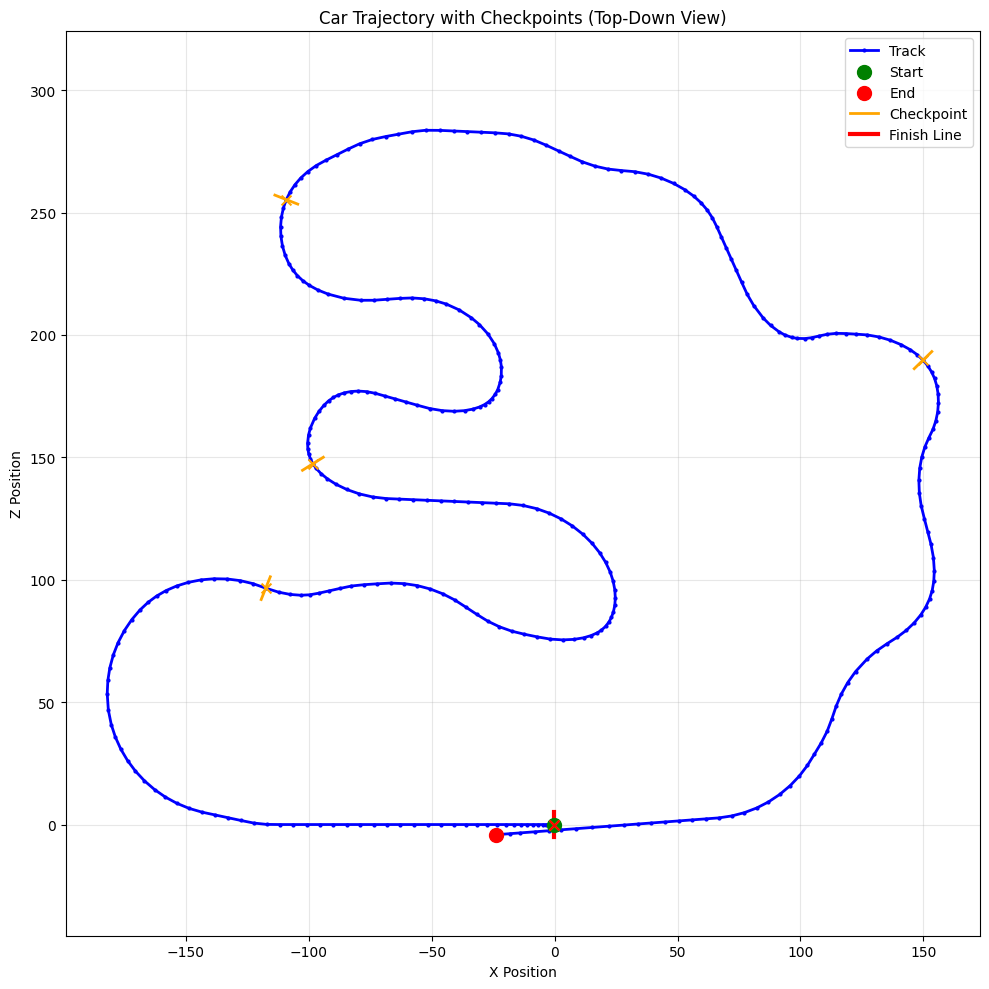

In [12]:
import matplotlib.pyplot as plt

# Extract X and Z positions
x_values = [s.car_position[0] for s in data]
z_values = [s.car_position[2] for s in data]

# Create 2D plot of the trajectory
plt.figure(figsize=(10, 10))
plt.plot(x_values, z_values, color='blue', linewidth=2, marker='o', markersize=2, label='Track')

# Mark start and end
plt.scatter(x_values[0], z_values[0], color='green', s=100, label='Start', zorder=5)
plt.scatter(x_values[-1], z_values[-1], color='red', s=100, label='End', zorder=5)

# Draw checkpoint lines
for cp in checkpoints:
    # Extract X and Z coordinates from point_a and point_b
    ax, az = cp['point_a'][0], cp['point_a'][2]
    bx, bz = cp['point_b'][0], cp['point_b'][2]

    # Draw line from point A to point B
    color = 'red' if cp['is_finish'] else 'orange'
    linewidth = 3 if cp['is_finish'] else 2
    label = 'Finish Line' if cp['is_finish'] else ('Checkpoint' if cp['checkpoint_id'] == 1 else None)

    plt.plot([ax, bx], [az, bz], color=color, linewidth=linewidth, label=label, zorder=4)

    # Optional: Mark checkpoint center
    plt.scatter(cp['center'][0], cp['center'][2], color=color, s=50, marker='x', zorder=5)

plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.title('Car Trajectory with Checkpoints (Top-Down View)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Keep aspect ratio square
plt.tight_layout()
plt.show()

In [13]:
def validate_checkpoint_order(data, checkpoints):
    current_checkpoint_idx = 0  # Next checkpoint we're expecting
    checkpoints_passed = []
    crossing_frames = []

    # Go through trajectory frame by frame
    for i in range(len(data) - 1):
        pos1 = data[i].car_position
        pos2 = data[i+1].car_position

        # Check if we crossed the CURRENT expected checkpoint
        if current_checkpoint_idx < len(checkpoints):
            expected_checkpoint = checkpoints[current_checkpoint_idx]

            if check_line_crossing(pos1, pos2, expected_checkpoint):
                # Passed the expected checkpoint!
                checkpoints_passed.append(expected_checkpoint['checkpoint_id'])
                crossing_frames.append(i)
                current_checkpoint_idx += 1

                print(f"✓ Checkpoint {expected_checkpoint['checkpoint_id']} passed at frame {i}")

    # Check if we passed ALL checkpoints
    all_passed = (current_checkpoint_idx == len(checkpoints))
    failed_at = None if all_passed else current_checkpoint_idx

    result = {
        'valid': all_passed,
        'checkpoints_passed': checkpoints_passed,
        'crossing_frames': crossing_frames,
        'failed_at': failed_at,
        'total_checkpoints': len(checkpoints),
        'checkpoints_completed': len(checkpoints_passed)
    }

    return result


# Test with your recorded data
print("=== Validating Recorded Run ===")
validation = validate_checkpoint_order(data, checkpoints)

print("\n=== Validation Results ===")
print(f"Valid run: {validation['valid']}")
print(f"Checkpoints passed: {validation['checkpoints_completed']}/{validation['total_checkpoints']}")
print(f"Checkpoint IDs: {validation['checkpoints_passed']}")
print(f"Crossing frames: {validation['crossing_frames']}")

if not validation['valid']:
    print(f"❌ Failed at checkpoint {validation['failed_at']}")
else:
    print("✅ All checkpoints passed in correct order!")

    # Calculate lap time (from first to last checkpoint)
    lap_frames = validation['crossing_frames'][-1] - validation['crossing_frames'][0]
    lap_time = lap_frames * 0.1  # 10 FPS = 0.1s per frame
    print(f"Lap time: {lap_time:.2f} seconds ({lap_frames} frames)")

=== Validating Recorded Run ===
✓ Checkpoint 0 passed at frame 0
✓ Checkpoint 1 passed at frame 65
✓ Checkpoint 2 passed at frame 131
✓ Checkpoint 3 passed at frame 196
✓ Checkpoint 4 passed at frame 262
✓ Checkpoint 5 passed at frame 322

=== Validation Results ===
Valid run: True
Checkpoints passed: 6/6
Checkpoint IDs: [0, 1, 2, 3, 4, 5]
Crossing frames: [0, 65, 131, 196, 262, 322]
✅ All checkpoints passed in correct order!
Lap time: 32.20 seconds (322 frames)
